In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from elpv_dataset.utils import load_dataset

images, defect_probability, cell_type = load_dataset()

print("Image array shape:", images.shape)
print("Defect labels shape:", defect_probability.shape)
print("Cell types shape:", cell_type.shape)

Image array shape: (2624, 300, 300)
Defect labels shape: (2624,)
Cell types shape: (2624,)


In [4]:
metadata = pd.DataFrame({
  "defect_probability" : defect_probability,
  "cell_type" : cell_type
})

metadata.head()

,defect_probability,cell_type
0,1.0,mono
1,1.0,mono
2,1.0,mono
3,0.0,mono
4,1.0,mono


In [5]:
print(metadata.info())
print()
print(metadata["defect_probability"].value_counts().sort_index())
print()
print(metadata["cell_type"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 2624 entries, 0 to 2623
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   defect_probability  2624 non-null   float64
 1   cell_type           2624 non-null   str    
dtypes: float64(1), str(1)
memory usage: 41.1 KB
None

defect_probability
0.000000    1508
0.333333     295
0.666667     106
1.000000     715
Name: count, dtype: int64

cell_type
poly    1550
mono    1074
Name: count, dtype: int64


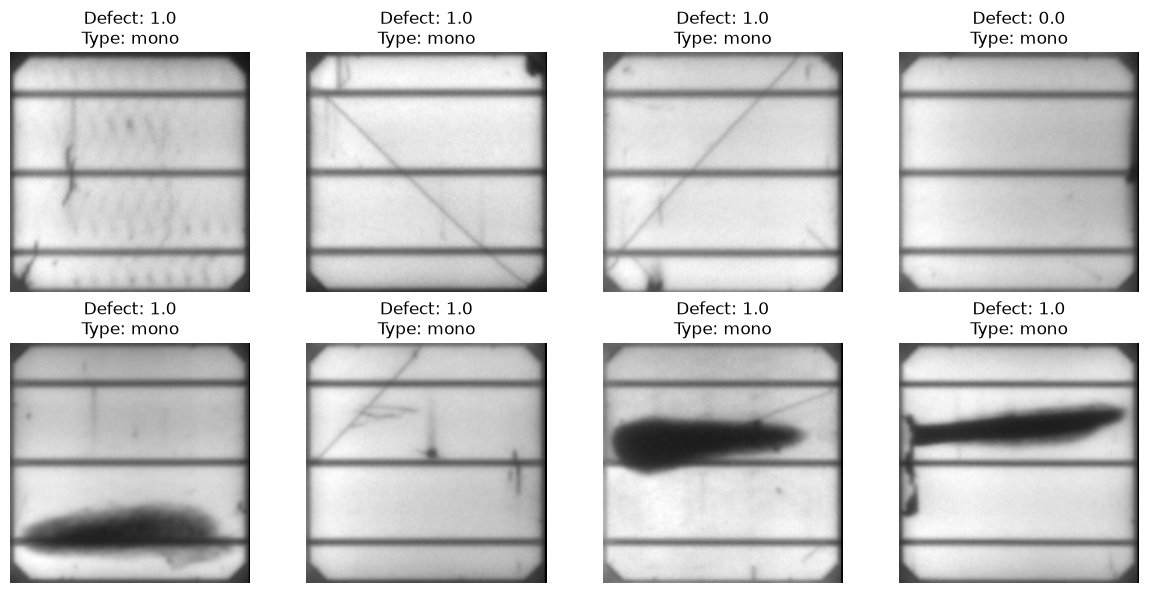

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for index, ax in enumerate(axes.flat):
    ax.imshow(images[index], cmap="gray")
    ax.set_title(
        f"Defect: {defect_probability[index]}\n"
        f"Type: {cell_type[index]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
label_counts = (
    metadata["defect_probability"]
    .value_counts()
    .sort_index()
)

label_percentages = label_counts / len(metadata) * 100

label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

label_summary

,count,percentage
defect_probability,,
0.000000,1508,57.47
0.333333,295,11.24
0.666667,106,4.04
1.000000,715,27.25


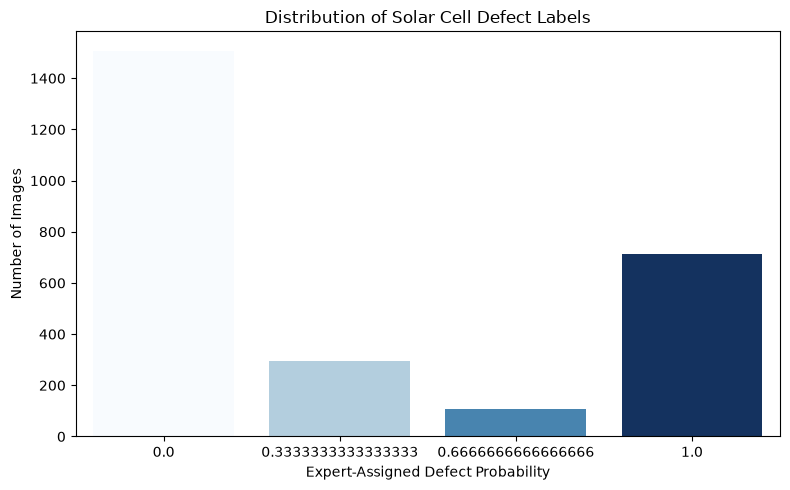

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=metadata,
    x="defect_probability",
    hue="defect_probability",
    palette="Blues",
    legend=False
)

plt.title("Distribution of Solar Cell Defect Labels")
plt.xlabel("Expert-Assigned Defect Probability")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.savefig(
    "../reports/figures/defect_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
type_defect_table = pd.crosstab(
    metadata["cell_type"],
    metadata["defect_probability"],
    margins=True
)

type_defect_table

defect_probability,0.0,0.333333,0.666667,1.0,All
cell_type,,,,,
mono,588,117,56,313,1074
poly,920,178,50,402,1550
All,1508,295,106,715,2624


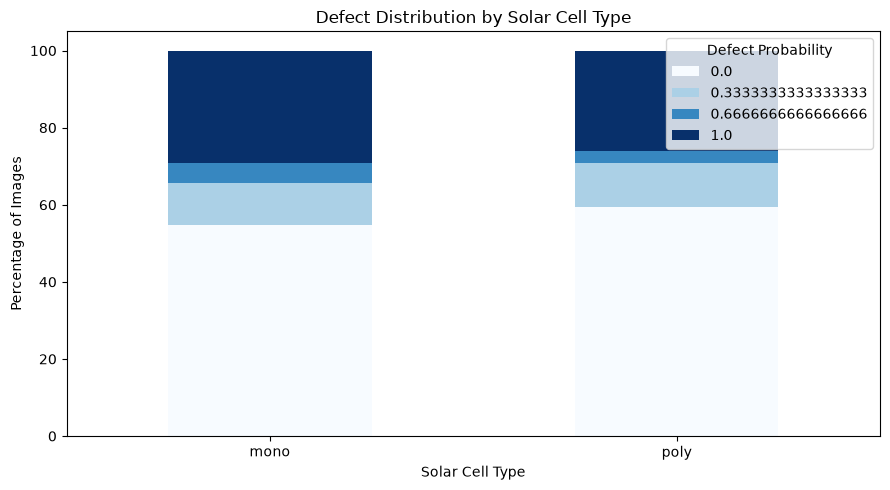

In [39]:
comparison = pd.crosstab(
    metadata["cell_type"],
    metadata["defect_probability"],
    normalize="index"
) * 100

comparison.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    colormap="Blues"
)

plt.title("Defect Distribution by Solar Cell Type")
plt.xlabel("Solar Cell Type")
plt.ylabel("Percentage of Images")
plt.xticks(rotation=0)
plt.legend(title="Defect Probability")
plt.tight_layout()

plt.savefig(
    "../reports/figures/defects_by_cell_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

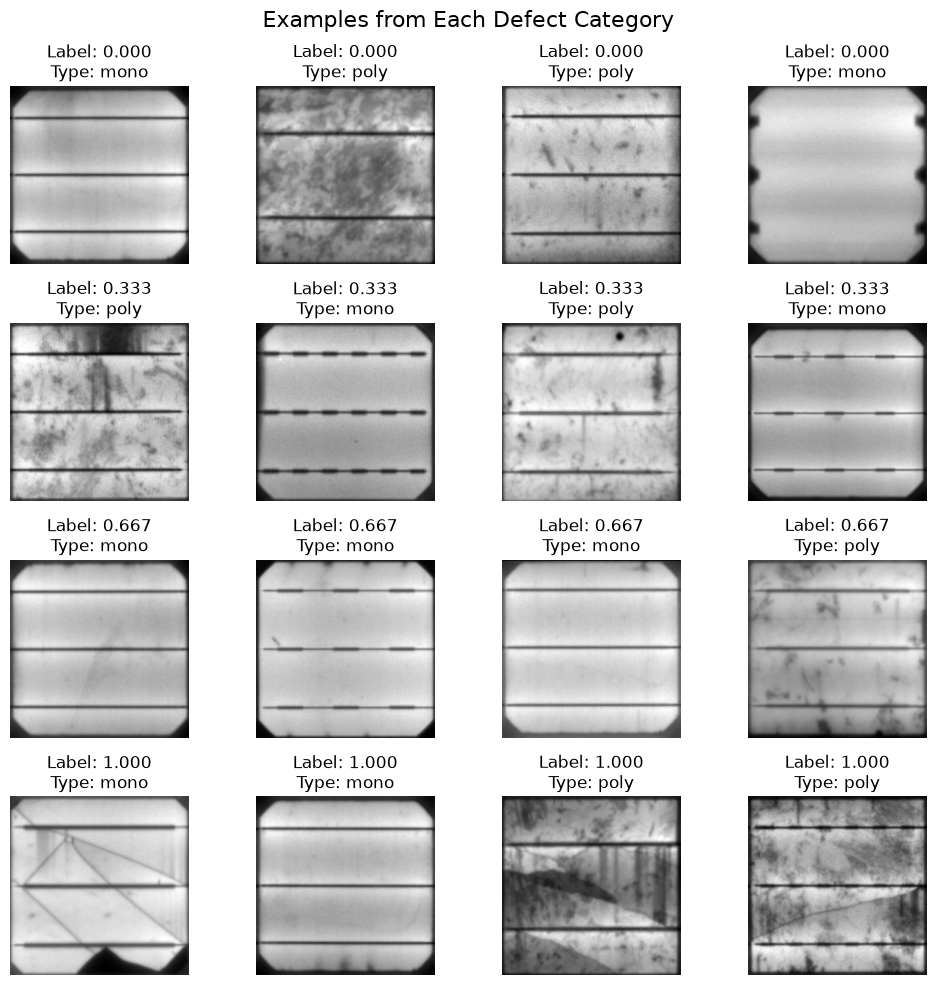

In [40]:
defect_levels = sorted(metadata["defect_probability"].unique())
random_generator = np.random.default_rng(seed=42)

fig, axes = plt.subplots(len(defect_levels), 4, figsize=(10, 10))

for row, defect_level in enumerate(defect_levels):
    matching_indices = np.where(defect_probability == defect_level)[0]

    selected_indices = random_generator.choice(
        matching_indices,
        size=4,
        replace=False
    )

    for column, image_index in enumerate(selected_indices):
        ax = axes[row, column]

        ax.imshow(images[image_index], cmap="gray")
        ax.set_title(
            f"Label: {defect_level:.3f}\n"
            f"Type: {cell_type[image_index]}"
        )
        ax.axis("off")

plt.suptitle(
    "Examples from Each Defect Category",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/defect_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Visual observations

- Cells labeled 0.0 generally seem to be pretty clean and contain few dark spots or cracks
- Cells labeled 1.0 generally show stronger defects such as harsh scratches, very dark regions, or cracks
- Intermediate labels appear to have small or less obvious defects, but are more difficult to determine
- Mono and poly cells differ visually because mono tend to have bended/rounded corners, while poly cells have a more rectangular image
- Some images may be difficult to classify because the darker cells cells still seem to appear normal, so defects probably rely on info on texture or edges